In [131]:
import pandas as pd

# Lire le fichier en sautant les 3 premières lignes inutiles
df = pd.read_csv("data/Palworld_Data-comparison of ordinary BOSS attributes.csv", skiprows=3)

# Afficher les premières lignes propres
df.head()


,name,HP,Unnamed: 2,name.1,Remote attack,Unnamed: 5,name.2,Riding speed (BOSS is 100 higher)
0,Chaos Knight BOSS,260.0,NaN,Melupa BOSS,90.0,NaN,Zixialu BOSS,1000
1,Chaos Knight,130.0,NaN,Melupa,75.0,NaN,Zixia Deer,900
2,Winter Caller Beast BOSS,420.0,NaN,Volt Meow BOSS,80.0,NaN,Suzaku BOSS,1200
3,Winter Caller,140.0,NaN,Volt Meow,75.0,NaN,Suzaku,1100
4,Night Caller BOSS,420.0,NaN,Snow Mammoth BOSS,90.0,NaN,Yunhailu BOSS,1150


In [15]:
# Supprimer les lignes entièrement vides
df.dropna(how='all', inplace=True)
# Vérifier les 5 premières lignes après nettoyage
df.shape  # Donne (nb_lignes, nb_colonnes)

(114, 8)

In [19]:
# Vérifier combien de valeurs manquantes par colonne
df.isna().sum()


name                                 104
HP                                   104
Unnamed: 2                           114
name.1                               108
Remote attack                        108
Unnamed: 5                           114
name.2                                 0
Riding speed (BOSS is 100 higher)      0
dtype: int64

In [22]:
df.shape         # Nombre total de lignes
df.dropna(subset=['name', 'HP']).shape  # Lignes conservées


(10, 6)

In [46]:
df_clean = df[df.count(axis=1) >= 4]

In [47]:
df.columns


Index(['name', 'HP', 'name.1', 'Remote attack', 'name.2',
       'Riding speed (BOSS is 100 higher)'],
      dtype='object')

In [34]:
df_clean.columns


Index(['name', 'HP', 'name.1', 'Remote attack', 'name.2',
       'Riding speed (BOSS is 100 higher)'],
      dtype='object')

In [36]:
df_clean.columns = ['boss_name', 'hp', 'alt_name_1', 'remote_attack', 'alt_name_2', 'riding_speed']


In [43]:
# Trier les boss par points de vie (HP) décroissants
df_top_hp = df_clean.sort_values(by='hp', ascending=False)

# Afficher les 10 premiers boss
df_top_hp.head(10)


,boss_name,hp,alt_name_1,remote_attack,alt_name_2,riding_speed
4,Night Caller BOSS,420.0,Snow Mammoth BOSS,90.0,Yunhailu BOSS,1150
2,Winter Caller Beast BOSS,420.0,Volt Meow BOSS,80.0,Suzaku BOSS,1200
6,Vortex Dragon BOSS,330.0,NaN,NaN,Hell Flame King BOSS,1000
0,Chaos Knight BOSS,260.0,Melupa BOSS,90.0,Zixialu BOSS,1000
8,Holy Light Knight BOSS,260.0,NaN,NaN,Hellfire King,900
5,Night Caller,140.0,snow mammoth,85.0,Cloud sea deer,1050
3,Winter Caller,140.0,Volt Meow,75.0,Suzaku,1100
1,Chaos Knight,130.0,Melupa,75.0,Zixia Deer,900
9,Knight of Light,130.0,NaN,NaN,Hell King,900
7,Vortex Dragon,110.0,NaN,NaN,Hell King BOSS,1000


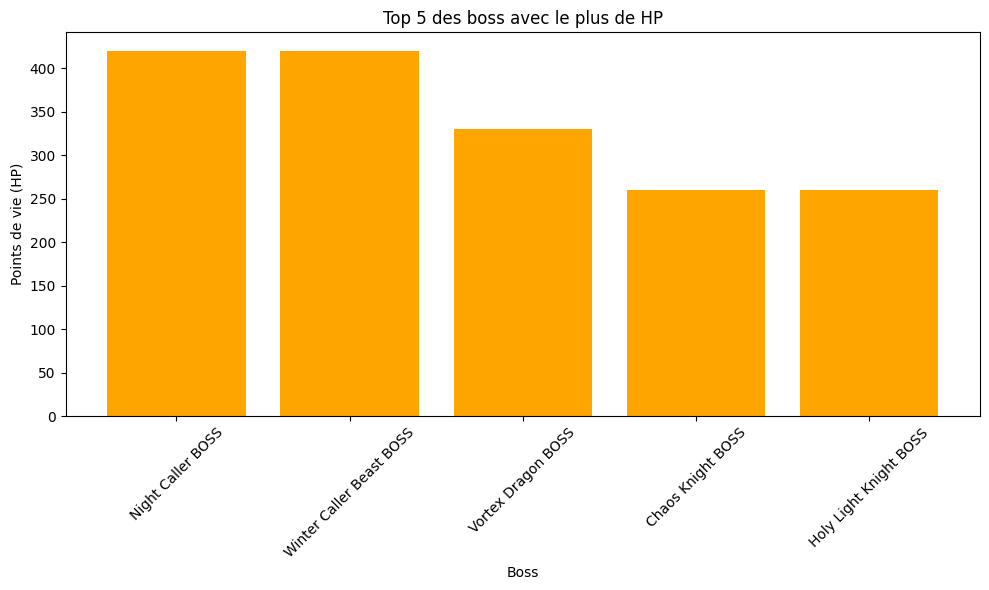

In [48]:
import matplotlib.pyplot as plt

# Sélectionner les 5 boss les plus puissants
top_5 = df_top_hp.head(5)

# Création du graphique
plt.figure(figsize=(10, 6))
plt.bar(top_5['boss_name'], top_5['hp'], color='orange')
plt.xlabel('Boss')
plt.ylabel('Points de vie (HP)')
plt.title('Top 5 des boss avec le plus de HP')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [51]:
df_clean.columns


Index(['name', 'HP', 'name.1', 'Remote attack', 'name.2',
       'Riding speed (BOSS is 100 higher)'],
      dtype='object')

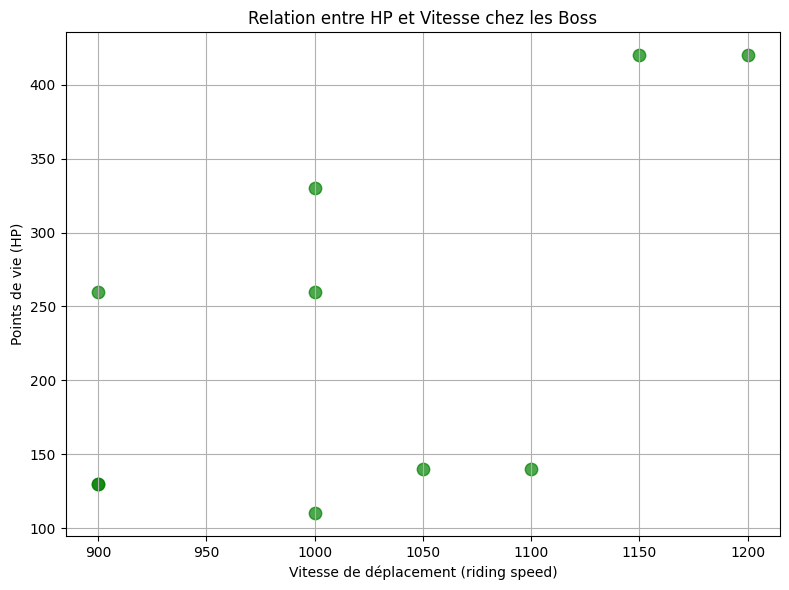

Corrélation HP / Vitesse : 0.59


In [53]:
# Étape 1 : Nettoyage des lignes avec valeurs manquantes
df_corr = df_clean.dropna(subset=['HP', 'Riding speed (BOSS is 100 higher)'])

# Étape 2 : Visualisation scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_corr['Riding speed (BOSS is 100 higher)'], df_corr['HP'], color='green', s=80, alpha=0.7)
plt.xlabel('Vitesse de déplacement (riding speed)')
plt.ylabel('Points de vie (HP)')
plt.title('Relation entre HP et Vitesse chez les Boss')
plt.grid(True)
plt.tight_layout()
plt.show()

# Étape 3 : Corrélation
correlation = df_corr['Riding speed (BOSS is 100 higher)'].corr(df_corr['HP'])
print(f"Corrélation HP / Vitesse : {correlation:.2f}")


In [55]:
correlation = df_corr['Riding speed (BOSS is 100 higher)'].corr(df_corr['HP'])
print(f"Corrélation HP / Vitesse : {correlation:.2f}")


Corrélation HP / Vitesse : 0.59


In [57]:
# Nettoyer les valeurs manquantes
df_attack = df_clean.dropna(subset=['Remote attack'])

# Trier par puissance d’attaque décroissante
df_top_attack = df_attack.sort_values(by='Remote attack', ascending=False)

# Afficher les 5 premiers
df_top_attack.head(5)


,name,HP,name.1,Remote attack,name.2,Riding speed (BOSS is 100 higher)
0,Chaos Knight BOSS,260.0,Melupa BOSS,90.0,Zixialu BOSS,1000
4,Night Caller BOSS,420.0,Snow Mammoth BOSS,90.0,Yunhailu BOSS,1150
5,Night Caller,140.0,snow mammoth,85.0,Cloud sea deer,1050
2,Winter Caller Beast BOSS,420.0,Volt Meow BOSS,80.0,Suzaku BOSS,1200
1,Chaos Knight,130.0,Melupa,75.0,Zixia Deer,900


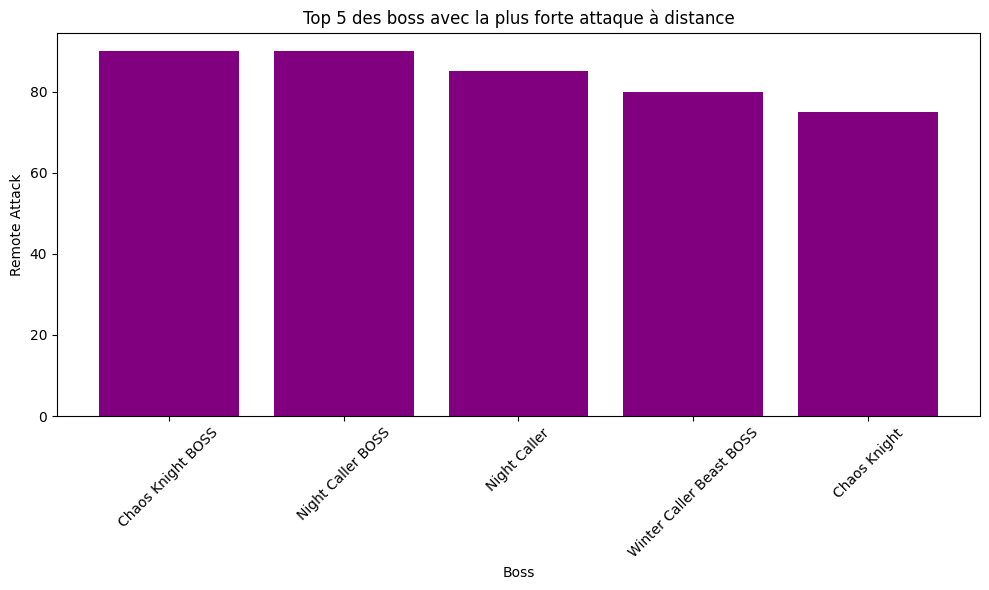

In [59]:
plt.figure(figsize=(10, 6))
plt.bar(df_top_attack['name'].head(5), df_top_attack['Remote attack'].head(5), color='purple')
plt.xlabel('Boss')
plt.ylabel('Remote Attack')
plt.title('Top 5 des boss avec la plus forte attaque à distance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [61]:
# Supprimer les lignes sans valeur dans Remote attack
df_attack = df_clean.dropna(subset=['Remote attack'])

# Trier par Remote attack décroissante
df_top_attack = df_attack.sort_values(by='Remote attack', ascending=False)

# Afficher les 5 boss les plus puissants à distance
df_top_attack.head(5)


,name,HP,name.1,Remote attack,name.2,Riding speed (BOSS is 100 higher)
0,Chaos Knight BOSS,260.0,Melupa BOSS,90.0,Zixialu BOSS,1000
4,Night Caller BOSS,420.0,Snow Mammoth BOSS,90.0,Yunhailu BOSS,1150
5,Night Caller,140.0,snow mammoth,85.0,Cloud sea deer,1050
2,Winter Caller Beast BOSS,420.0,Volt Meow BOSS,80.0,Suzaku BOSS,1200
1,Chaos Knight,130.0,Melupa,75.0,Zixia Deer,900


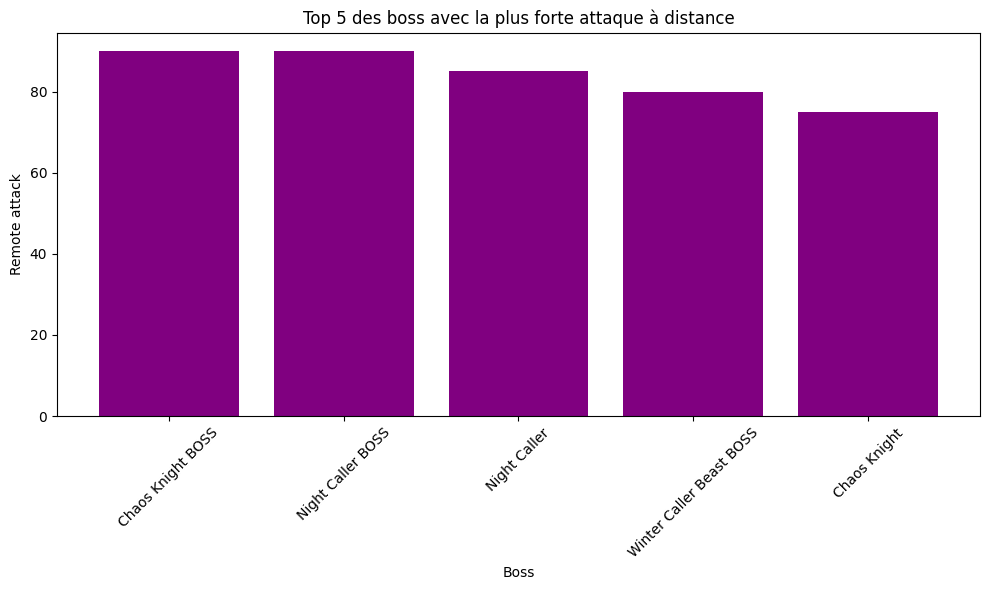

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(df_top_attack['name'].head(5), df_top_attack['Remote attack'].head(5), color='purple')
plt.xlabel('Boss')
plt.ylabel('Remote attack')
plt.title('Top 5 des boss avec la plus forte attaque à distance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [65]:
# S'assurer que les colonnes nécessaires n'ont pas de NaN
df_ratio = df_clean.dropna(subset=['HP', 'Riding speed (BOSS is 100 higher)'])

# Créer une nouvelle colonne avec le ratio HP / vitesse
df_ratio['hp_per_speed'] = df_ratio['HP'] / df_ratio['Riding speed (BOSS is 100 higher)']

# Afficher les boss avec le meilleur ratio
df_ratio_sorted = df_ratio.sort_values(by='hp_per_speed', ascending=False)
df_ratio_sorted.head(5)


,name,HP,name.1,Remote attack,name.2,Riding speed (BOSS is 100 higher),hp_per_speed
4,Night Caller BOSS,420.0,Snow Mammoth BOSS,90.0,Yunhailu BOSS,1150,0.365217
2,Winter Caller Beast BOSS,420.0,Volt Meow BOSS,80.0,Suzaku BOSS,1200,0.350000
6,Vortex Dragon BOSS,330.0,NaN,NaN,Hell Flame King BOSS,1000,0.330000
8,Holy Light Knight BOSS,260.0,NaN,NaN,Hellfire King,900,0.288889
0,Chaos Knight BOSS,260.0,Melupa BOSS,90.0,Zixialu BOSS,1000,0.260000


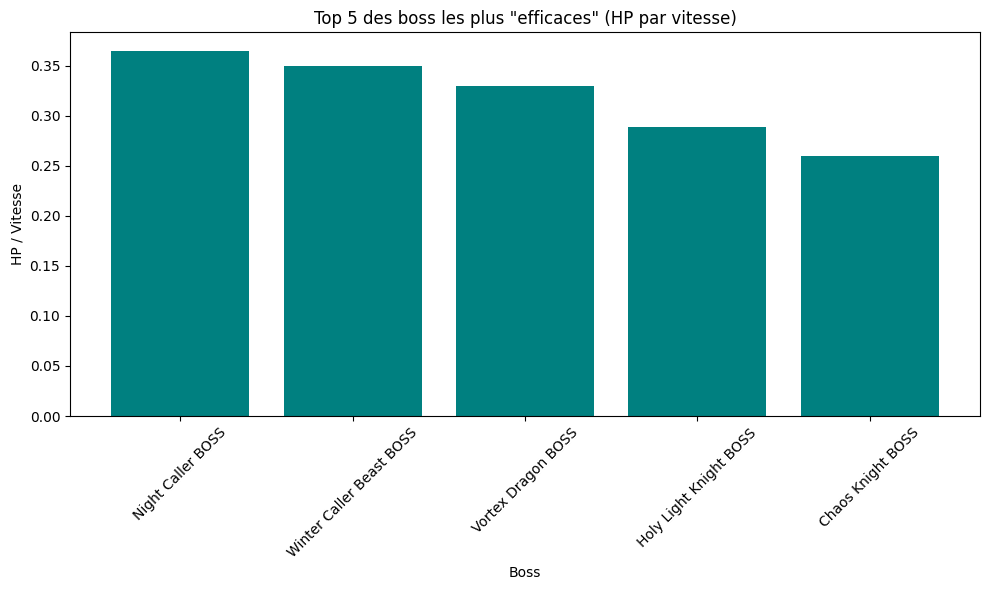

In [67]:
plt.figure(figsize=(10, 6))
plt.bar(df_ratio_sorted['name'].head(5), df_ratio_sorted['hp_per_speed'].head(5), color='teal')
plt.xlabel('Boss')
plt.ylabel('HP / Vitesse')
plt.title('Top 5 des boss les plus "efficaces" (HP par vitesse)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [80]:
# Reprendre un DataFrame propre avec les colonnes utiles
df_final = df_clean.dropna(subset=['HP', 'Remote attack', 'Riding speed (BOSS is 100 higher)']).copy()

# Renommer les colonnes pour plus de lisibilité
df_final.rename(columns={
    'name': 'Boss',
    'HP': 'HP',
    'Remote attack': 'Remote_Attack',
    'Riding speed (BOSS is 100 higher)': 'Riding_Speed'
}, inplace=True)

# Ajouter le ratio HP / vitesse
df_final['HP_per_Speed'] = df_final['HP'] / df_final['Riding_Speed']

# Trier si tu veux voir les meilleurs "équilibres"
df_final.sort_values(by='HP_per_Speed', ascending=False, inplace=True)

# Afficher le tableau final
df_final.head()


,Boss,HP,name.1,Remote_Attack,name.2,Riding_Speed,HP_per_Speed
4,Night Caller BOSS,420.0,Snow Mammoth BOSS,90.0,Yunhailu BOSS,1150,0.365217
2,Winter Caller Beast BOSS,420.0,Volt Meow BOSS,80.0,Suzaku BOSS,1200,0.350000
0,Chaos Knight BOSS,260.0,Melupa BOSS,90.0,Zixialu BOSS,1000,0.260000
1,Chaos Knight,130.0,Melupa,75.0,Zixia Deer,900,0.144444
5,Night Caller,140.0,snow mammoth,85.0,Cloud sea deer,1050,0.133333


## Analyse : Données de combat des Pals


In [77]:
import pandas as pd

# Lire le fichier
df_combat = pd.read_csv("data/Palworld_Data--Palu combat attribute table.csv")

# Afficher les premières lignes
df_combat.head()


,Table of Contents Palu Job Skill Table Skill Learning Level Tower BOSS Attributes Comparison with Normal BOSS Attributes Comparison of Partner Skill Values Individual Value Calculator,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 40,Unnamed: 41,Unnamed: 42,Partner skills,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49
0,ID,Chinese name,Name,CodeName,OverrideNameTextID,NamePrefixID,OverridePartnerSkillTextID,IsPal,Tribe,BPClass,...,price,Must bring entry 1,Must bring entry 2,Numerical description,lv1,lv2,lv3,lv4,lv5,Skill description
1,1,Mian Youyou,Lamball,SheepBall,NaN,NaN,NaN,TRUE,EPalTribeID::SheepBall,SheepBall,...,1000,NaN,NaN,Ranch skills,0,0,0,0,0,"When activated, it will transform into a shiel..."
2,2,Naughty cat,Cattiva,PinkCat,NaN,NaN,NaN,TRUE,EPalTribeID::PinkCat,PinkCat,...,1000,timid,NaN,Increased weight bearing,50,60,70,80,90,"If PinkCat is in the team, it will help carry ..."
3,3,Pipi Chicken,Chikipi,ChickenPal,NaN,NaN,NaN,TRUE,EPalTribeID::ChickenPal,ChickenPal,...,1000,NaN,NaN,Ranch skills,0,0,0,0,0,Assign it to Palu Ranch and it will have a cha...
4,4,green leaf rat,Lifmunk,Carbunclo,NaN,NaN,NaN,TRUE,EPalTribeID::Carbunclo,Carbunclo,...,1010,NaN,NaN,Skill power,10,11,13,16,20,"After being activated, it will sit on the play..."


In [83]:
# Voir la structure du tableau
df_combat.info()

# Voir les colonnes disponibles
df_combat.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 50 columns):
 #   Column                                                                                                                                                                                   Non-Null Count  Dtype 
---  ------                                                                                                                                                                                   --------------  ----- 
 0   Table of Contents Palu Job Skill Table Skill Learning Level Tower BOSS Attributes Comparison with Normal BOSS Attributes Comparison of Partner Skill Values Individual Value Calculator  139 non-null    object
 1   Unnamed: 1                                                                                                                                                                               139 non-null    object
 2   Unnamed: 2                            

Index(['Table of Contents Palu Job Skill Table Skill Learning Level Tower BOSS Attributes Comparison with Normal BOSS Attributes Comparison of Partner Skill Values Individual Value Calculator',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'Non-bonus panel attack power range reference', 'Unnamed: 28',
       'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32',
       'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36',
       'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40',
       'Unnamed: 41', 'Unnamed: 42', 'Partner skills', 'Unnamed: 44',
       'Unnamed: 45', 'Unnamed: 46', 'Unna

In [85]:
df_combat.columns


Index(['Table of Contents Palu Job Skill Table Skill Learning Level Tower BOSS Attributes Comparison with Normal BOSS Attributes Comparison of Partner Skill Values Individual Value Calculator',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'Non-bonus panel attack power range reference', 'Unnamed: 28',
       'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32',
       'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36',
       'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40',
       'Unnamed: 41', 'Unnamed: 42', 'Partner skills', 'Unnamed: 44',
       'Unnamed: 45', 'Unnamed: 46', 'Unna

In [87]:
df_combat = pd.read_csv("data/Palworld_Data--Palu combat attribute table.csv", skiprows=6)
df_combat.head()


,5,tinder fox,Foxparks,Kitsunebi,None,None.1,None.2,TRUE,EPalTribeID::Kitsunebi,Kitsunebi.1,...,1040,Unnamed: 41,Unnamed: 42,Skill power,10,11,13,16,20,"When activated, it will transform into a flamethrower equipped on the player."
0,6,surf duck,Fuack,BluePlatypus,NaN,NaN,NaN,True,EPalTribeID::Blueplatypus,BluePlatypus,...,1120,NaN,NaN,Skill power multiplier,1,1.1,1.3,1.6,2,"When activated, BluePlatypus will ride the wav..."
1,7,Volt Meow,Sparkit,ElecCat,NaN,NaN,NaN,True,EPalTribeID::ElecCat,ElecCat,...,1030,NaN,NaN,Attack power bonus%,10,11,13,16,20,"If it is in the team, the elemental Electricit..."
2,8,Neolepithecus,Tanzee,Monkey,NaN,NaN,NaN,True,EPalTribeID::Monkey,Monkey,...,1280,NaN,NaN,Skill power,20,22,26,32,40,"After activation, Monkey will violently shoot ..."
3,9,Fire Deer,Rooby,FlameBambi,NaN,NaN,NaN,True,EPalTribeID::FlameBambi,FlameBambi,...,2950,NaN,NaN,Attack power bonus%,10,11,13,16,20,"If it is in the team, the elemental Fire Palu'..."
4,10,Keimaru,Pengullet,Penguin,NaN,NaN,NaN,True,EPalTribeID::Penguin,Penguin,...,1080,NaN,NaN,Skill power,250,285,325,400,500,"After activation, players will equip Launcher_..."


In [89]:
df_combat.columns
df_combat.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 50 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   5                                                                              133 non-null    int64  
 1   tinder fox                                                                     133 non-null    object 
 2   Foxparks                                                                       133 non-null    object 
 3   Kitsunebi                                                                      133 non-null    object 
 4   None                                                                           1 non-null      object 
 5   None.1                                                                         0 non-null      float64
 6   None.2                    

In [90]:
df_combat.rename(columns={
    'tinder fox': 'Code Name',
    'Foxparks': 'Pal Name (EN)',
    'Kitsunebi': 'Pal Name (JP)',
    'XS': 'Size',
    '1': 'Rarity',
    'fire': 'Element',
    'EPalGenusCategoryType::FourLegged': 'Category',
    'EPalOrganizationType::None': 'Organization',
    '280': 'HP',
    '65': 'Attack',
    '70': 'Defense',
    '70.1': 'Support',
    'Skill power': 'Skill Power',
    'When activated, it will transform into a flamethrower equipped on the player.': 'Skill Description'
}, inplace=True)


In [92]:
# Supprimer les colonnes avec trop de NaN ou avec 'Unnamed'
df_combat.drop(columns=[col for col in df_combat.columns if "Unnamed" in col or "None" in col], inplace=True)


In [94]:
cols_to_keep = ['Pal Name (EN)', 'Code Name', 'Size', 'Rarity', 'Element', 'Category', 'Organization',
                'HP', 'Attack', 'Defense', 'Support', 'Skill Power', 'Skill Description']
df_combat = df_combat[cols_to_keep]


In [96]:
df_combat.columns


Index(['Pal Name (EN)', 'Code Name', 'Size', 'Rarity', 'Element', 'Category',
       'Organization', 'HP', 'Attack', 'Defense', 'Support', 'Skill Power',
       'Skill Description'],
      dtype='object')

In [98]:
df_combat.head(1).T


,0
Pal Name (EN),Fuack
Code Name,surf duck
Size,XS
Rarity,1
Element,water
Category,EPalGenusCategoryType::Humanoid
Organization,EPalOrganizationType::None
HP,280
Attack,60
Defense,80


In [101]:
df_combat.head()


,Pal Name (EN),Code Name,Size,Rarity,Element,Category,Organization,HP,Attack,Defense,Support,Skill Power,Skill Description
0,Fuack,surf duck,XS,1,water,EPalGenusCategoryType::Humanoid,EPalOrganizationType::None,280,60,80,60,Skill power multiplier,"When activated, BluePlatypus will ride the wav..."
1,Sparkit,Volt Meow,XS,1,electricity,EPalGenusCategoryType::Humanoid,EPalOrganizationType::None,265,60,60,70,Attack power bonus%,"If it is in the team, the elemental Electricit..."
2,Tanzee,Neolepithecus,XS,1,Wood,EPalGenusCategoryType::Humanoid,EPalOrganizationType::None,320,80,100,70,Skill power,"After activation, Monkey will violently shoot ..."
3,Rooby,Fire Deer,S,2,fire,EPalGenusCategoryType::FourLegged,EPalOrganizationType::None,320,75,100,75,Attack power bonus%,"If it is in the team, the elemental Fire Palu'..."
4,Pengullet,Keimaru,XS,1,water,EPalGenusCategoryType::Humanoid,EPalOrganizationType::None,285,70,70,70,Skill power,"After activation, players will equip Launcher_..."


## 🔍 Analyse des attributs cachés des Pals


In [104]:
import pandas as pd

# Essai avec 3 lignes ignorées
df_hidden = pd.read_csv("data/Palworld_Data-hide pallu attributes.csv", skiprows=3)

# Aperçu
df_hidden.head()


,Marcus & Horus,GYM_Horus,PAL_NAME_DessertBoss,GYM_NAME_Desert,PARTNERSKILL_orus,TRUE,EPalTribeID::Horus,GYM_Horus.1,-2,Unnamed: 9,...,0.6,0.7,0.8,0.9,3.1,0.10,None.2,None.3,None.4,None.5
0,Lily & Lily Queen,GYM_LilyQueen,PAL_NAME_ForestBoss,GYM_NAME_Forest,PARTNERSKILL_ilyQueen,True,EPalTribeID::LilyQueen,GYM_LilyQueen,-2,NaN,...,0,0,3,0,0,0,NaN,NaN,NaN,NaN
1,Axel & Pollux,GYM_ThunderDragonMan,PAL_NAME_VolcanoBoss,GYM_NAME_Volcano,PARTNERSKILL_hunderDragonMan,True,EPalTribeID::ThunderDragonMan,GYM_ThunderDragonMan,-2,NaN,...,0,0,0,0,3,0,NaN,NaN,NaN,NaN
2,does not appear in the game,BadCatgirl,NaN,NaN,NaN,True,EPalTribeID::BadCatgirl,BadCatgirl,-1,NaN,...,0,0,0,0,2,0,NaN,NaN,NaN,NaN
3,does not appear in the game,BlueberryFairy,NaN,NaN,NaN,True,EPalTribeID::BlueberryFairy,BlueberryFairy,-1,NaN,...,0,0,3,0,1,0,NaN,NaN,NaN,NaN
4,Melupa,BOSS_Alpaca,PAL_NAME_Alpaca,BOSS_NAME_Alpaca,PARTNERSKILL_Alpaca,True,EPalTribeID::Alpaca,BOSS_Alpaca,-1,NaN,...,0,0,0,0,0,1,NaN,NaN,NaN,NaN


In [106]:
df_hidden.info()
df_hidden.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 71 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Marcus & Horus                174 non-null    object 
 1   GYM_Horus                     174 non-null    object 
 2   PAL_NAME_DessertBoss          157 non-null    object 
 3   GYM_NAME_Desert               157 non-null    object 
 4   PARTNERSKILL_orus             157 non-null    object 
 5   TRUE                          174 non-null    bool   
 6   EPalTribeID::Horus            174 non-null    object 
 7   GYM_Horus.1                   174 non-null    object 
 8   -2                            174 non-null    int64  
 9   Unnamed: 9                    0 non-null      float64
 10  XL                            174 non-null    object 
 11  9                             174 non-null    int64  
 12  Fire                          174 non-null    object 
 13  None 

Index(['Marcus & Horus', 'GYM_Horus', 'PAL_NAME_DessertBoss',
       'GYM_NAME_Desert', 'PARTNERSKILL_orus', 'TRUE', 'EPalTribeID::Horus',
       'GYM_Horus.1', '-2', 'Unnamed: 9', 'XL', '9', 'Fire', 'None',
       'EPalGenusCategoryType::Bird', 'EPalOrganizationType::None',
       'EPalWeaponType::None', 'FALSE', '6500', '100', '120', '125', '90',
       '100.1', '100%', '100%.1', '30', '6720', 'Warlike', 'None.1', '150',
       '200', '1000', '1300', '500', 'TRUE.1', 'TRUE.2',
       'EPalBattleBGMType::TowerBoss', 'TRUE.3', 'TRUE.4', '525', '1', '8',
       '25', '90.1', '1.1', 'FALSE.1', 'FALSE.2', '9.1', 'FALSE.3', 'TRUE.5',
       '100.2', '100.3', '9999', '3', '0', '0.1', '0.2', '0.3', '0.4', '0.5',
       '0.6', '0.7', '0.8', '0.9', '3.1', '0.10', 'None.2', 'None.3', 'None.4',
       'None.5'],
      dtype='object')

In [108]:
# Supprimer les colonnes vides ou inutiles
df_hidden_clean = df_hidden.drop(columns=[
    col for col in df_hidden.columns 
    if 'Unnamed' in col or 'None' in col or 'TRUE' in col or 'FALSE' in col or df_hidden[col].isna().all()
])


In [110]:
df_hidden_clean.rename(columns={
    'Marcus & Horus': 'Boss Name',
    'GYM_Horus': 'Gym Code',
    'PAL_NAME_DessertBoss': 'Pal Name',
    'PARTNERSKILL_orus': 'Partner Skill',
    'EPalTribeID::Horus': 'Tribe ID',
    'Fire': 'Element',
    'Warlike': 'Disposition',
    'EPalGenusCategoryType::Bird': 'Category'
}, inplace=True)


In [112]:
df_streamlit = df_hidden_clean[[
    'Boss Name', 'Pal Name', 'Gym Code', 'Partner Skill', 'Tribe ID', 'Element', 'Disposition', 'Category'
]]


## 📘 Palworld – Job Skills des Pals


In [114]:
import pandas as pd

# Lire le fichier en sautant les 3 premières lignes d'intro si besoin
df_jobs = pd.read_csv("data/Palworld_Data-Palu Job Skills Table.csv", skiprows=3)

# Afficher les premières lignes
df_jobs.head()


,2,Cattiva,Naughty cat,smallest,2.1,Unnamed: 5,4,0,0.1,0.2,...,0.4,1.2,0.5,0.6,0.7,1.3,160,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,3,Chikipi,Pipi Chicken,smallest,1,NaN,2,0,0,0,...,0,0,0,0,1,0,NaN,Egg,1,Rank
1,4,Lifmunk,green leaf rat,smallest,1,NaN,5,0,0,1,...,1,0,1,0,0,0,NaN,NaN,NaN,NaN
2,5,Foxparks,tinder fox,smallest,2,NaN,1,1,0,0,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
3,6,Fuack,surf duck,smallest,2,NaN,3,0,1,0,...,0,0,0,0,0,1,202.0,NaN,NaN,NaN
4,7,Sparkit,Volt Meow,smallest,2,NaN,3,0,0,0,...,0,0,0,0,0,1,270.0,NaN,NaN,NaN


In [116]:
df_jobs.info()
df_jobs.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   2            136 non-null    int64  
 1   Cattiva      136 non-null    object 
 2   Naughty cat  136 non-null    object 
 3   smallest     136 non-null    object 
 4   2.1          136 non-null    int64  
 5   Unnamed: 5   25 non-null     object 
 6   4            136 non-null    int64  
 7   0            136 non-null    int64  
 8   0.1          136 non-null    int64  
 9   0.2          136 non-null    int64  
 10  0.3          136 non-null    int64  
 11  1            136 non-null    int64  
 12  1.1          136 non-null    int64  
 13  0.4          136 non-null    int64  
 14  1.2          136 non-null    int64  
 15  0.5          136 non-null    int64  
 16  0.6          136 non-null    int64  
 17  0.7          136 non-null    int64  
 18  1.3          136 non-null    int64  
 19  160     

Index(['2', 'Cattiva', 'Naughty cat', 'smallest', '2.1', 'Unnamed: 5', '4',
       '0', '0.1', '0.2', '0.3', '1', '1.1', '0.4', '1.2', '0.5', '0.6', '0.7',
       '1.3', '160', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')

In [119]:
# Supprimer les colonnes inutiles
df_jobs_clean = df_jobs.drop(columns=[
    col for col in df_jobs.columns if 'Unnamed' in col or df_jobs[col].isna().sum() > 100
])


In [121]:
df_jobs_clean.rename(columns={
    'Cattiva': 'Pal Name (JP)',
    'Naughty cat': 'Pal Name (EN)',
    'smallest': 'Size',
    '2': 'Pal ID'
}, inplace=True)


In [123]:
df_jobs_clean.info()
df_jobs_clean.head(1).T  # pour voir les colonnes verticalement


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pal ID         136 non-null    int64  
 1   Pal Name (JP)  136 non-null    object 
 2   Pal Name (EN)  136 non-null    object 
 3   Size           136 non-null    object 
 4   2.1            136 non-null    int64  
 5   4              136 non-null    int64  
 6   0              136 non-null    int64  
 7   0.1            136 non-null    int64  
 8   0.2            136 non-null    int64  
 9   0.3            136 non-null    int64  
 10  1              136 non-null    int64  
 11  1.1            136 non-null    int64  
 12  0.4            136 non-null    int64  
 13  1.2            136 non-null    int64  
 14  0.5            136 non-null    int64  
 15  0.6            136 non-null    int64  
 16  0.7            136 non-null    int64  
 17  1.3            136 non-null    int64  
 18  160       

,0
Pal ID,3
Pal Name (JP),Chikipi
Pal Name (EN),Pipi Chicken
Size,smallest
2.1,1
4,2
0,0
0.1,0
0.2,0
0.3,0


In [125]:
# Colonnes descriptives (à garder à gauche)
meta_cols = ['Pal ID', 'Pal Name (JP)', 'Pal Name (EN)', 'Size']

# Toutes les autres sont considérées comme skills
skill_cols = [col for col in df_jobs_clean.columns if col not in meta_cols]

# Créer un nouveau DataFrame avec les colonnes organisées
df_skills = df_jobs_clean[meta_cols + skill_cols]


In [127]:
# Aperçu des colonnes skills
print("Compétences métiers détectées :")
print(skill_cols)

# Vérifier la distribution des valeurs dans les skills
df_skills[skill_cols].describe()


Compétences métiers détectées :
['2.1', '4', '0', '0.1', '0.2', '0.3', '1', '1.1', '0.4', '1.2', '0.5', '0.6', '0.7', '1.3', '160']


,2.1,4,0,0.1,0.2,0.3,1,1.1,0.4,1.2,0.5,0.6,0.7,1.3,160
count,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.00000,54.000000
mean,4.588235,4.198529,0.338235,0.220588,0.264706,0.169118,0.580882,0.485294,0.485294,0.338235,0.220588,0.257353,0.088235,0.75000,282.629630
std,2.259041,2.721165,0.853929,0.706490,0.701694,0.627224,0.899013,0.798010,0.877583,0.862559,0.663226,0.730259,0.284685,1.08696,104.199427
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,100.000000
25%,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,225.000000
50%,5.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,272.500000
75%,7.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.00000,342.500000
max,9.000000,12.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,4.000000,1.000000,4.00000,500.000000


In [128]:
# Filtrer les Pals avec au moins une compétence > 0
df_with_skills = df_skills[df_skills[skill_cols].sum(axis=1) > 0]

# Afficher les 5 premiers
df_with_skills.head()


,Pal ID,Pal Name (JP),Pal Name (EN),Size,2.1,4,0,0.1,0.2,0.3,1,1.1,0.4,1.2,0.5,0.6,0.7,1.3,160
0,3,Chikipi,Pipi Chicken,smallest,1,2,0,0,0,0,0,1,0,0,0,0,1,0,NaN
1,4,Lifmunk,green leaf rat,smallest,1,5,0,0,1,0,1,1,1,0,1,0,0,0,NaN
2,5,Foxparks,tinder fox,smallest,2,1,1,0,0,0,0,0,0,0,0,0,0,0,NaN
3,6,Fuack,surf duck,smallest,2,3,0,1,0,0,1,0,0,0,0,0,0,1,202.0
4,7,Sparkit,Volt Meow,smallest,2,3,0,0,0,1,1,0,0,0,0,0,0,1,270.0
